In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set()


In [19]:
DATA_DIR = Path('data')
OUTPUT_DIR = DATA_DIR
SAMPLE_SIZES = {'train': 180, 'test': 90, 'val': 90}
COLUMNS_TO_DROP = ['author', 'subreddit', 'link_id', 'parent_id', 
                  'created_utc', 'rater_id', 'example_very_unclear']

In [20]:
def load_raw_data():
    """Load and concatenate all raw GoEmotions CSV files."""
    dfs = []
    for i in range(1, 4):
        file_path = DATA_DIR / 'full_dataset' / f'goemotions_{i}.csv'
        dfs.append(pd.read_csv(file_path))
    return pd.concat(dfs, ignore_index=True)

def load_split_file(filename):
    """Load a split file (train/test/dev TSV)."""
    return pd.read_csv(DATA_DIR / filename, delimiter='\t', header=None)

def process_split(df_raw, split_df, split_name):
    """
    Process a data split (train/test/val).
    
    Args:
        df_raw: Raw DataFrame containing all data
        split_df: DataFrame with split information
        split_name: Name of the split ('train', 'test', or 'val')
    
    Returns:
        Processed and sampled DataFrame
    """
    # Filter and clean data
    df = df_raw[df_raw.id.isin(split_df.iloc[:, 2])].drop_duplicates('id')
    df = df[df.example_very_unclear == False]
    df = df.drop(COLUMNS_TO_DROP, axis=1)
    
    # Sample data
    emotion_columns = df.columns[2:]  # Skip text and id columns
    sampled_data = pd.DataFrame()
    sample_size = SAMPLE_SIZES[split_name]
    
    for emotion in emotion_columns:
        filtered_data = df[df[emotion] == 1]
        sampled_data = pd.concat([
            sampled_data,
            filtered_data.sample(min(sample_size, len(filtered_data)))
        ])
    
    sampled_data.reset_index(drop=True, inplace=True)
    
    # Save and visualize
    OUTPUT_DIR.mkdir(exist_ok=True)
    sampled_data.to_csv(OUTPUT_DIR / f'{split_name}.csv', index=False)
    
    # Calculate distribution
    emotion_counts = sampled_data[emotion_columns].sum()
    total_samples = len(sampled_data)
    percent_dist = (emotion_counts / total_samples * 100).round(1)
    
    # Multi-label analysis
    num_labels_per_sample = sampled_data[emotion_columns].sum(axis=1)
    avg_labels = num_labels_per_sample.mean().round(2)
    
    # Create combined DataFrame
    dist_df = pd.DataFrame({
        'Count': emotion_counts,
        'Percent': percent_dist
    }).sort_values('Count', ascending=False)
    
    # Print report
    print(f"\n=== {split_name.upper()} SET DISTRIBUTION ===")
    print(f"Total samples: {total_samples}")
    print(f"Average labels per sample: {avg_labels}\n")
    print(dist_df.to_string(formatters={'Percent': '{:.1f}%'.format}))
    
    # Imbalance metrics
    imbalance_ratio = emotion_counts.max() / emotion_counts.min()
    print(f"\nClass imbalance ratio: {imbalance_ratio:.1f}x (max/min)")
    print("Most common emotion:", emotion_counts.idxmax())
    print("Least common emotion:", emotion_counts.idxmin())

    sns.barplot(data=sampled_data.iloc[:,2:].sum(), orient='h')
    plt.title(f'Emotion Distribution - {split_name}')
    plt.tight_layout()
    plt.show()
    
    return sampled_data


Processing train split...

=== TRAIN SET DISTRIBUTION ===
Total samples: 4985
Average labels per sample: 1.54

                Count Percent
admiration        418    8.4%
approval          373    7.5%
gratitude         335    6.7%
annoyance         333    6.7%
sadness           329    6.6%
optimism          319    6.4%
disappointment    310    6.2%
joy               298    6.0%
realization       296    5.9%
disapproval       291    5.8%
curiosity         291    5.8%
amusement         289    5.8%
love              289    5.8%
fear              279    5.6%
excitement        277    5.6%
disgust           268    5.4%
anger             264    5.3%
caring            263    5.3%
surprise          253    5.1%
confusion         247    5.0%
desire            247    5.0%
nervousness       247    5.0%
remorse           225    4.5%
embarrassment     224    4.5%
relief            198    4.0%
pride             193    3.9%
neutral           180    3.6%
grief             141    2.8%

Class imbalance r

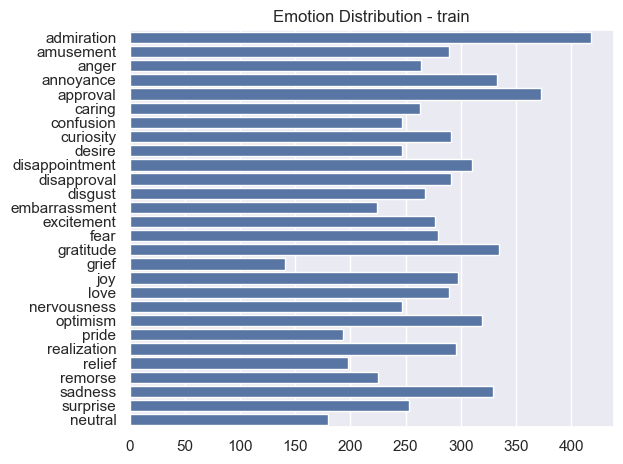


Processing test split...

=== TEST SET DISTRIBUTION ===
Total samples: 2230
Average labels per sample: 1.51

                Count Percent
admiration        186    8.3%
approval          173    7.8%
annoyance         157    7.0%
realization       155    7.0%
gratitude         152    6.8%
curiosity         152    6.8%
optimism          148    6.6%
disapproval       145    6.5%
sadness           144    6.5%
joy               142    6.4%
love              140    6.3%
disappointment    139    6.2%
excitement        132    5.9%
caring            131    5.9%
anger             130    5.8%
confusion         124    5.6%
amusement         123    5.5%
disgust           123    5.5%
desire            116    5.2%
surprise          116    5.2%
fear              113    5.1%
neutral            90    4.0%
embarrassment      83    3.7%
remorse            82    3.7%
nervousness        78    3.5%
pride              47    2.1%
relief             41    1.8%
grief              15    0.7%

Class imbalance rat

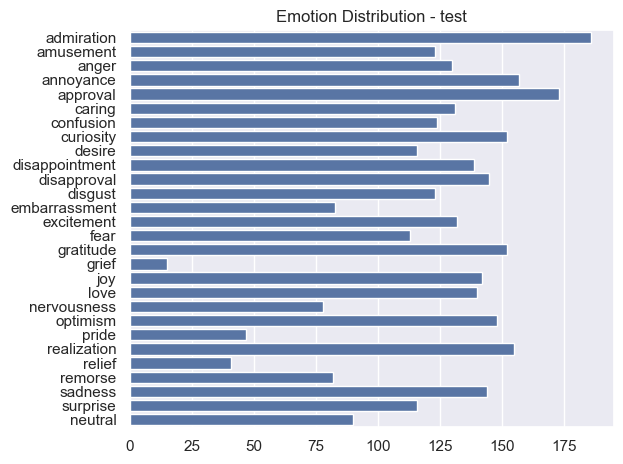


Processing val split...

=== VAL SET DISTRIBUTION ===
Total samples: 2178
Average labels per sample: 1.59

                Count Percent
admiration        193    8.9%
approval          185    8.5%
realization       175    8.0%
annoyance         161    7.4%
gratitude         160    7.3%
optimism          159    7.3%
disappointment    157    7.2%
sadness           149    6.8%
disapproval       147    6.7%
love              143    6.6%
anger             138    6.3%
curiosity         137    6.3%
joy               135    6.2%
surprise          133    6.1%
amusement         131    6.0%
disgust           131    6.0%
caring            131    6.0%
excitement        130    6.0%
confusion         125    5.7%
desire            116    5.3%
remorse            92    4.2%
neutral            90    4.1%
fear               89    4.1%
embarrassment      69    3.2%
nervousness        59    2.7%
relief             46    2.1%
pride              41    1.9%
grief              32    1.5%

Class imbalance ratio

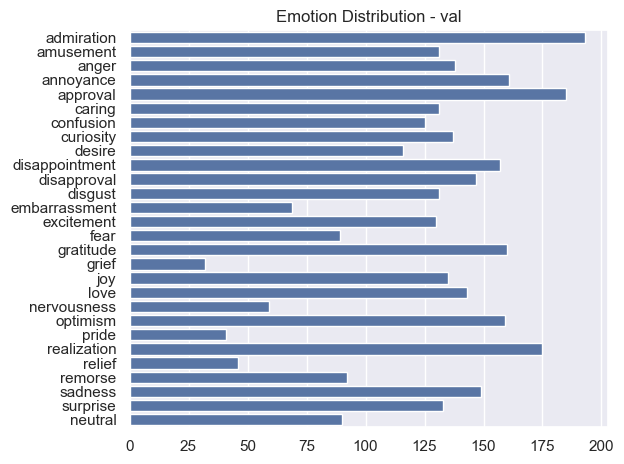

In [21]:
def main():
    # Load data
    df_raw = load_raw_data()
    
    # Process each split
    splits = {
        'train': 'train.tsv',
        'test': 'test.tsv',
        'val': 'dev.tsv'
    }
    
    for split_name, filename in splits.items():
        print(f"\nProcessing {split_name} split...")
        split_df = load_split_file(filename)
        _ = process_split(df_raw, split_df, split_name)

if __name__ == '__main__':
    main()